# 06 · Interpretabilidade e aplicação estratégica

Os notebooks anteriores entregaram três coisas: um modelo que prevê se o aluno será alfabetizado, um modelo de risco municipal com projeção para 2026 e quatro perfis de município. Este notebook abre os modelos com SHAP e usa tudo isso para responder, uma a uma, às cinco perguntas estratégicas do desafio:

1. Quais fatores mais impactam a alfabetização?
2. Quais municípios apresentam maior risco educacional?
3. Quais regiões possuem padrões semelhantes?
4. Como prever municípios que podem não atingir metas futuras?
5. Quais variáveis possuem maior influência nos modelos?

O SHAP (valores de Shapley aplicados a modelos) atribui a cada variável a contribuição marginal média para cada previsão. É exato para modelos de árvore (TreeExplainer) e tem as propriedades que fazem dele a referência para explicação: as contribuições somam a diferença entre a previsão e a média, e variáveis com o mesmo efeito recebem o mesmo crédito. Todos os gráficos usam rótulos de negócio no lugar dos nomes técnicos.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from src.data.abt import carregar_abt_aluno
from src.preprocessing.features import grupos_aluno, grupos_municipio, preparar_xy
from src.modeling.train import carregar_modelo
from src.evaluation.interpretabilidade import explicar, importancia_shap, importancia_por_grupo, importancia_permutacao
from src.visualization.estilo import aplicar_estilo, salvar, fmt_pct, AZUL, LARANJA, CINZA, VERDE, VERMELHO, PALETA, CORES_REGIAO
from src.visualization.mapas import carregar_malha, mapa_municipios
from src.visualization.rotulos import rotulo

aplicar_estilo()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
SEED = 42

modelo_aluno = carregar_modelo("modelo_aluno")
modelo_municipio = carregar_modelo("modelo_municipio")
meta_aluno = json.loads(Path("models/modelo_aluno.json").read_text(encoding="utf-8"))
meta_municipio = json.loads(Path("models/modelo_municipio.json").read_text(encoding="utf-8"))
print("aluno:", meta_aluno["modelo"], "| município:", meta_municipio["modelo"])

aluno: lightgbm | município: lightgbm


/home/cosme/Desktop/ai-scientist-masters/phase-03/tech-challenge/repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. O que pesa no modelo do aluno

O SHAP é calculado em uma amostra de 5 mil alunos de 2025 (o conjunto de teste, para explicar o comportamento do modelo em dado novo).

In [2]:
alunos = carregar_abt_aluno()
teste = alunos[alunos["ano"] == 2025]
ga = grupos_aluno()
x_teste, y_teste = preparar_xy(teste, ga, "alfabetizado")
shap_aluno, xt_aluno = explicar(modelo_aluno, x_teste, max_amostras=5000, seed=SEED)
imp_aluno = importancia_shap(shap_aluno)
imp_aluno.head(15).round(4)

,variavel,importancia_shap
0,% alfabetizados no ano anterior,0.1956
1,Salto necessário para a meta (p.p.),0.1413
2,Presença na prova na escola (%),0.1157
3,IDEB anos iniciais (última edição),0.1021
4,Nota de português no Saeb 5o ano (última edição),0.0683
5,UF: RS,0.0530
6,UF: MG,0.0485
7,UF: BA,0.0378
8,UF: SP,0.0340
9,Rede de ensino: estadual,0.0246


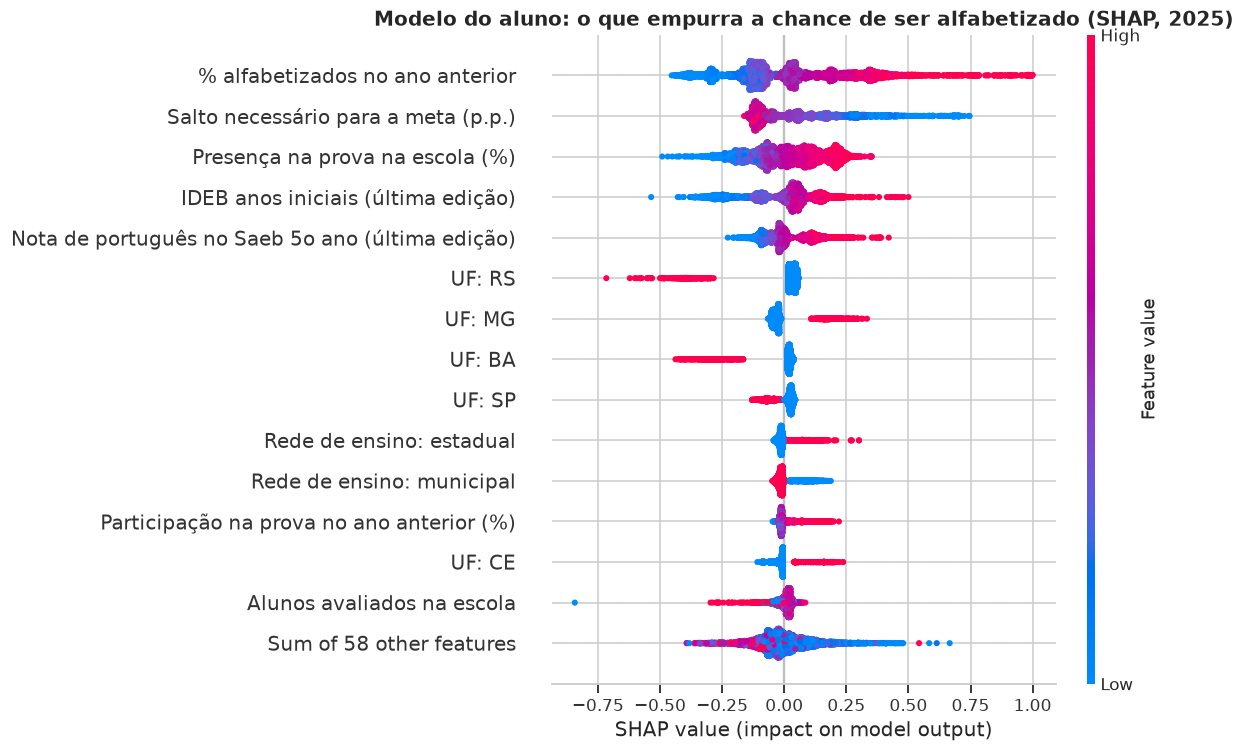

In [3]:
fig = plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_aluno, max_display=15, show=False)
plt.title("Modelo do aluno: o que empurra a chance de ser alfabetizado (SHAP, 2025)")
plt.gcf().set_size_inches(11, 7)
salvar(plt.gcf(), "06_shap_aluno_beeswarm")
plt.show()

In [4]:
bloco_aluno = importancia_por_grupo(imp_aluno, {"histórico do indicador": ga["historico"], "porte e tamanho": ga["log"], "contexto (censo, rendimento, ideb, socioeconômico, escola)": ga["numericas"]})
bloco_aluno

,% da importância
bloco,
"contexto (censo, rendimento, ideb, socioeconômico, escola)",40.2
histórico do indicador,30.9
territorio (UF) e rede,24.9
porte e tamanho,4.1


No grão de aluno, a variável que mais move a previsão é o **histórico do município** (o percentual do ano anterior), seguida do **salto necessário para a meta**, da **presença na prova na escola**, do **IDEB** e da **UF**. Somando por bloco, o contexto (Censo Escolar, rendimento, IDEB, socioeconômico e escola) pesa 40%, o histórico 31% e UF e rede 25%. A leitura de política: a probabilidade de uma criança ser alfabetizada é, antes de tudo, uma propriedade da rede em que ela estuda, e o sinal mais barato de acompanhar é a frequência à prova, que reflete a frequência à escola.

### 1.1 Variante para uso antes da prova

Duas variáveis do modelo do aluno são medidas no dia da prova: a presença na prova na escola e o número de alunos avaliados na escola. Elas não são derivadas do resultado (não é vazamento do alvo), mas só existem quando a prova acontece, então o modelo completo serve para explicar o resultado depois da aplicação, não para triagem antes do ano letivo. Para essa segunda finalidade, a variante abaixo usa só variáveis conhecidas antes da prova: rede, UF e o contexto municipal. Mesmos hiperparâmetros, mesmo treino em 2024 com pesos, mesmo teste em 2025.

In [5]:
from lightgbm import LGBMClassifier
from sklearn.base import clone

from src.preprocessing.pipeline import build_pipeline
from src.evaluation.metricas import avaliar_classificacao

treino = alunos[alunos["ano"] == 2024]
ga_antes = {
    "historico": ga["historico"],
    "log": [c for c in ga["log"] if c != "escola_qtd_avaliados"],
    "numericas": [c for c in ga["numericas"] if c != "escola_taxa_presenca"],
    "categoricas": ga["categoricas"],
}
hiper = meta_aluno["hiperparametros"]
x_tr_a, y_tr_a = preparar_xy(treino, ga_antes, "alfabetizado")
modelo_antes = build_pipeline(ga_antes, LGBMClassifier(n_estimators=600, learning_rate=0.03, random_state=SEED, n_jobs=-1, verbose=-1, **hiper))
modelo_antes.fit(x_tr_a, y_tr_a, modelo__sample_weight=treino["peso"].values)
x_te_a, y_te_a = preparar_xy(teste, ga_antes, "alfabetizado")
proba_antes = modelo_antes.predict_proba(x_te_a)[:, 1]
proba_completo = modelo_aluno.predict_proba(x_teste)[:, 1]
w_te = teste["peso"].values
comparacao_variantes = pd.DataFrame({
    "completo (com presença e tamanho da escola)": avaliar_classificacao(y_teste.values, proba_completo, meta_aluno["limiar_operacao"], w_te),
    "antes da prova (sem as variáveis de escola)": avaliar_classificacao(y_te_a.values, proba_antes, meta_aluno["limiar_operacao"], w_te),
}).T[["auc_roc", "auc_pr", "recall_negativos", "precisao_negativos", "acuracia"]]
comparacao_variantes.round(3)

,auc_roc,auc_pr,recall_negativos,precisao_negativos,acuracia
completo (com presença e tamanho da escola),0.646,0.776,0.689,0.428,0.577
antes da prova (sem as variáveis de escola),0.641,0.772,0.668,0.426,0.577


Sem as duas variáveis de escola o AUC no teste de 2025 cai pouco: o modelo perde a informação de frequência, que é o sinal mais forte no nível da escola, mas mantém a ordenação pelo contexto municipal. Para triagem antes do ano letivo é esta variante que deve ser usada, com o limiar reestimado; para leitura do resultado depois da prova, a completa. A distinção fica registrada no README e nas decisões analíticas.

## 2. O que pesa no modelo do município

O modelo de município prevê o nível do indicador (o percentual de alfabetizados), e o risco vem da comparação com a meta. O SHAP aqui explica o nível previsto para 2026, em pontos percentuais.

In [6]:
abt = pd.read_parquet("data/processed/abt_municipio.parquet")
proj = abt[(abt["ano_alvo"] == 2026) & abt["meta_t"].notna()].copy()
gm = grupos_municipio()
x_proj, _ = preparar_xy(proj.assign(atingiu_meta_t=0), gm, "atingiu_meta_t")
shap_mun, xt_mun = explicar(modelo_municipio, x_proj, max_amostras=len(x_proj), seed=SEED)
imp_mun = importancia_shap(shap_mun)
imp_mun.head(15).round(3)

,variavel,importancia_shap
0,% alfabetizados no ano anterior,6.441
1,IDEB anos iniciais (última edição),1.721
2,UF: SP,1.249
3,UF: RS,1.215
4,Participação na prova no ano anterior (%),0.951
5,Salto necessário para a meta (p.p.),0.882
6,População (Censo 2022),0.681
7,Nota de português no Saeb 5o ano (última edição),0.676
8,IDEB anos iniciais (edição anterior),0.667
9,"Taxa de abandono, anos iniciais (%)",0.629


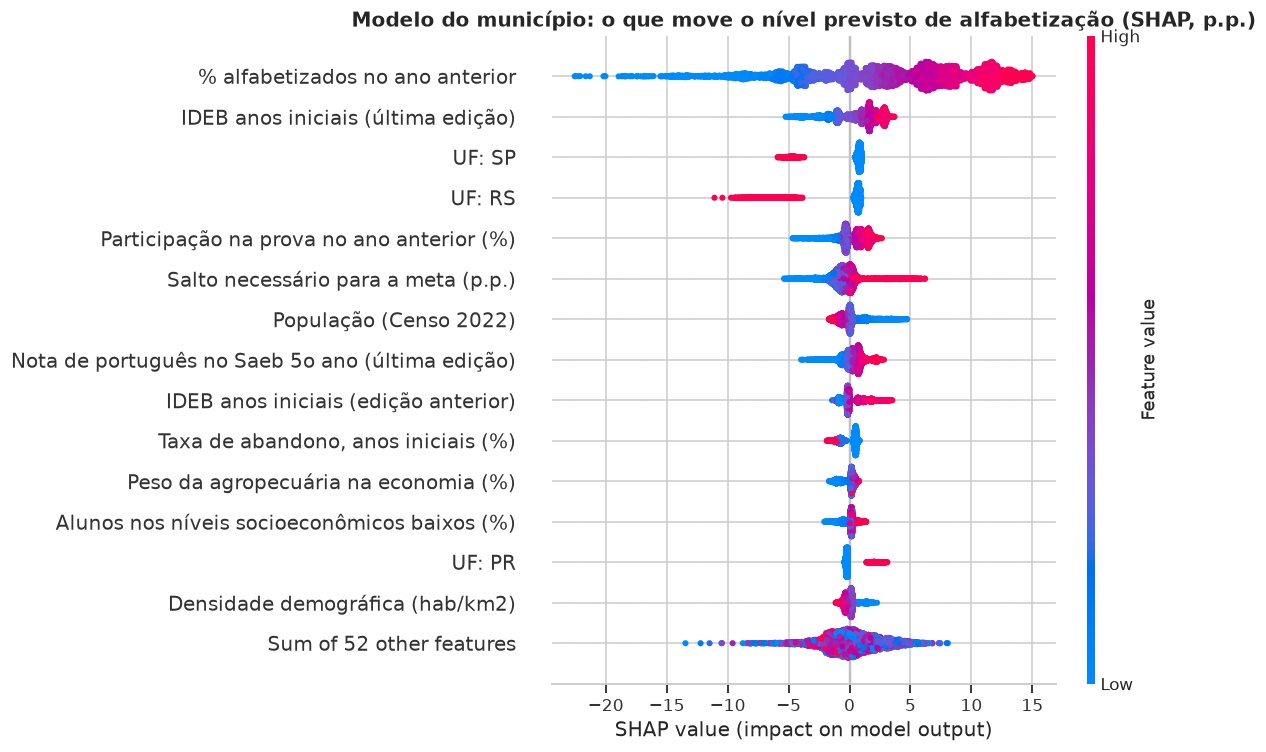

In [7]:
fig = plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_mun, max_display=15, show=False)
plt.title("Modelo do município: o que move o nível previsto de alfabetização (SHAP, p.p.)")
plt.gcf().set_size_inches(11, 7)
salvar(plt.gcf(), "06_shap_municipio_beeswarm")
plt.show()

In [8]:
bloco_mun = importancia_por_grupo(imp_mun, {"histórico do indicador": gm["historico"], "porte e renda": gm["log"], "censo escolar, rendimento, ideb e socioeconômico": gm["numericas"]})
bloco_mun

,% da importância
bloco,
histórico do indicador,37.9
"censo escolar, rendimento, ideb e socioeconômico",34.0
territorio (UF) e rede,20.5
porte e renda,7.6


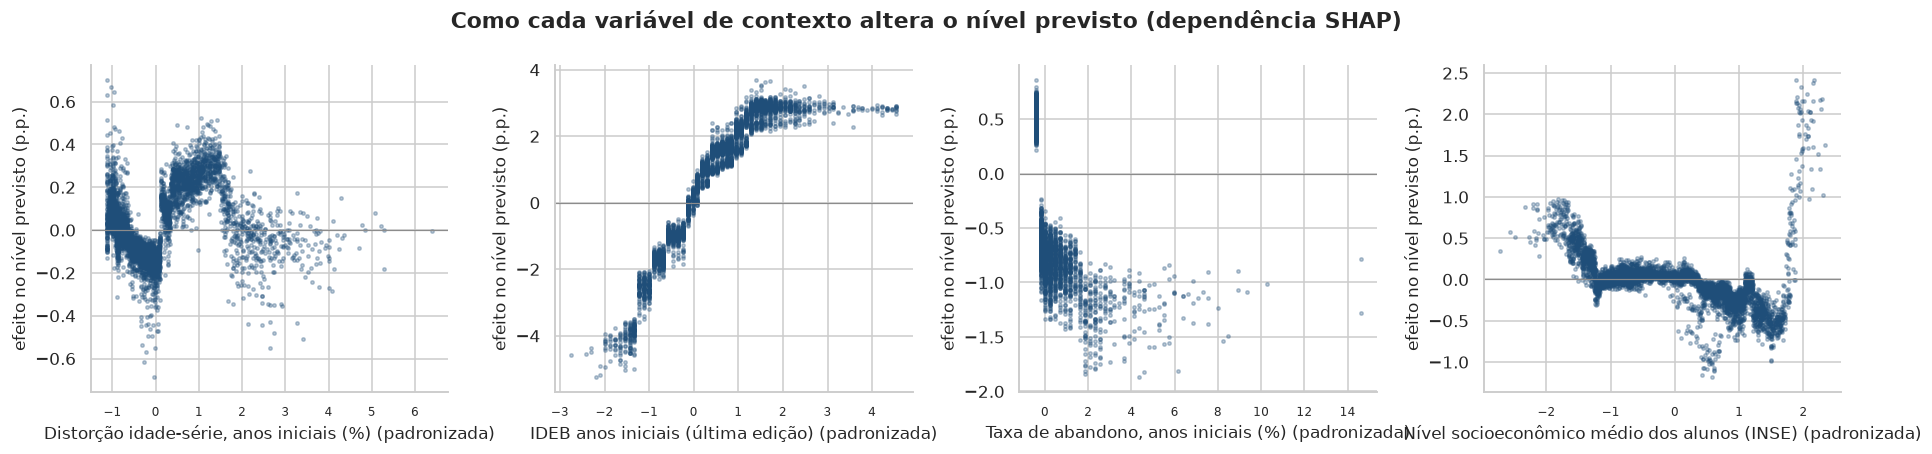

In [9]:
# dependencia parcial via SHAP para as variaveis de contexto mais fortes
nomes = list(shap_mun.feature_names)
candidatas = [rotulo(c) for c in ["distorcao_ai_pct", "ideb_ultimo", "abandono_ai_pct", "inse_medio"]]
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, nome in zip(axes, candidatas):
    j = nomes.index(nome)
    ax.scatter(xt_mun.iloc[:, j], shap_mun.values[:, j], s=5, alpha=0.3, color=AZUL)
    ax.axhline(0, color=CINZA, lw=0.8)
    ax.set_xlabel(nome + " (padronizada)")
    ax.set_ylabel("efeito no nível previsto (p.p.)")
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Como cada variável de contexto altera o nível previsto (dependência SHAP)", fontweight="bold")
salvar(fig, "06_shap_dependencia")
plt.show()

As curvas de dependência mostram o que a importância média esconde. O IDEB tem efeito forte e monotônico, de −4 a +3 pontos no nível previsto, com saturação nos extremos. O abandono funciona como um degrau: abandono zero nos anos iniciais vale meio ponto a mais; qualquer abandono custa cerca de um ponto, e não importa muito quanto. Distorção idade-série e INSE, que na EDA tinham correlação clara com o resultado, pesam pouco dentro do modelo (menos de um ponto), porque o histórico e o IDEB já carregam essa informação; é o efeito da colinearidade que a matriz de correlação antecipava. A leitura para o gestor: distorção e abandono continuam bons sinais de alerta, mas o que o modelo usa para prever é o resultado passado da rede.

In [10]:
# importancia por permutacao (segunda opiniao, sobre as colunas originais e o AUC do risco derivado nao se aplica; usa-se o erro do nivel)
com_alvo = abt[abt["atingiu_meta_t"].notna()]
x_val, _ = preparar_xy(com_alvo, gm, "atingiu_meta_t")
perm = importancia_permutacao(modelo_municipio, x_val, com_alvo["indicador_t"].astype(float).values, n_repeats=5, seed=SEED, scoring="neg_mean_absolute_error")
perm = perm.rename(columns={"queda_auc": "aumento_do_erro_pp"})
perm.head(12).round(3)

,variavel,aumento_do_erro_pp,desvio
0,% alfabetizados no ano anterior,4.715,0.044
1,UF,1.137,0.024
2,IDEB anos iniciais (última edição),0.615,0.022
3,Participação na prova no ano anterior (%),0.398,0.024
4,Nota de português no Saeb 5o ano (última edição),0.220,0.013
5,Salto necessário para a meta (p.p.),0.207,0.012
6,População (Censo 2022),0.187,0.012
7,IDEB anos iniciais (edição anterior),0.096,0.008
8,"Taxa de aprovação, anos iniciais (%)",0.088,0.002
9,"Taxa de abandono, anos iniciais (%)",0.069,0.006


## 3. Explicação local: por que este município está em risco

Para o gestor, a explicação global é menos útil do que a explicação do seu município. O gráfico em cascata mostra, para um município no topo da lista de risco de 2026, como cada variável move a previsão a partir da média nacional. E o contraste com um município do perfil consolidado mostra o que separa os dois.

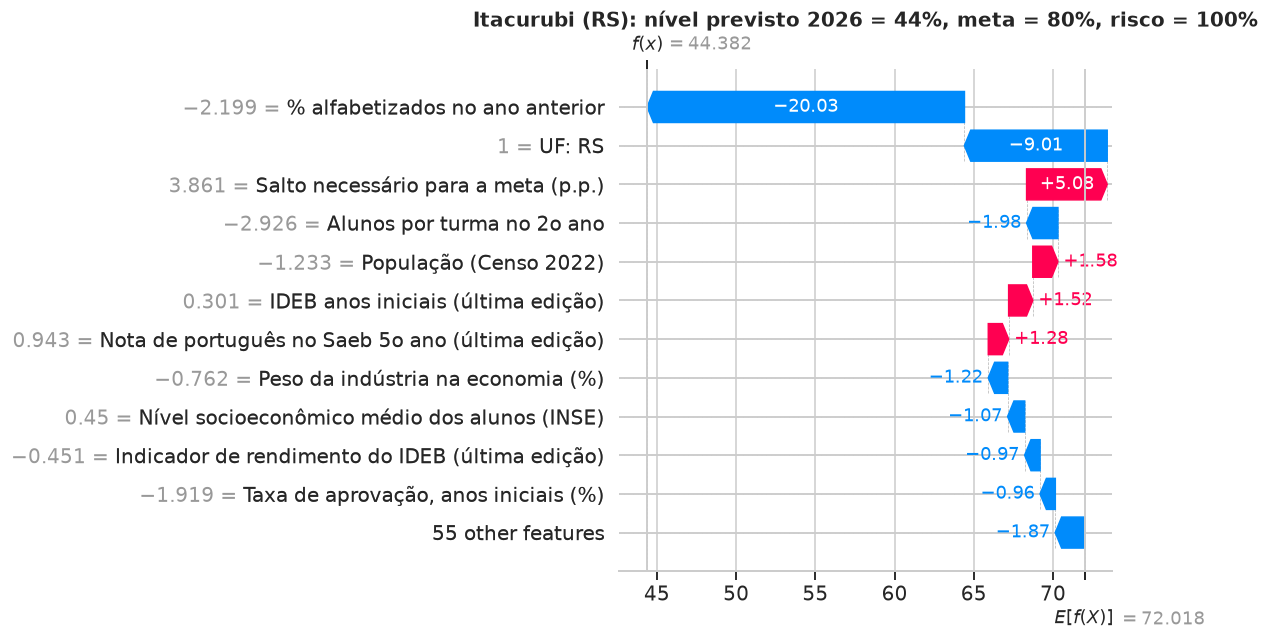

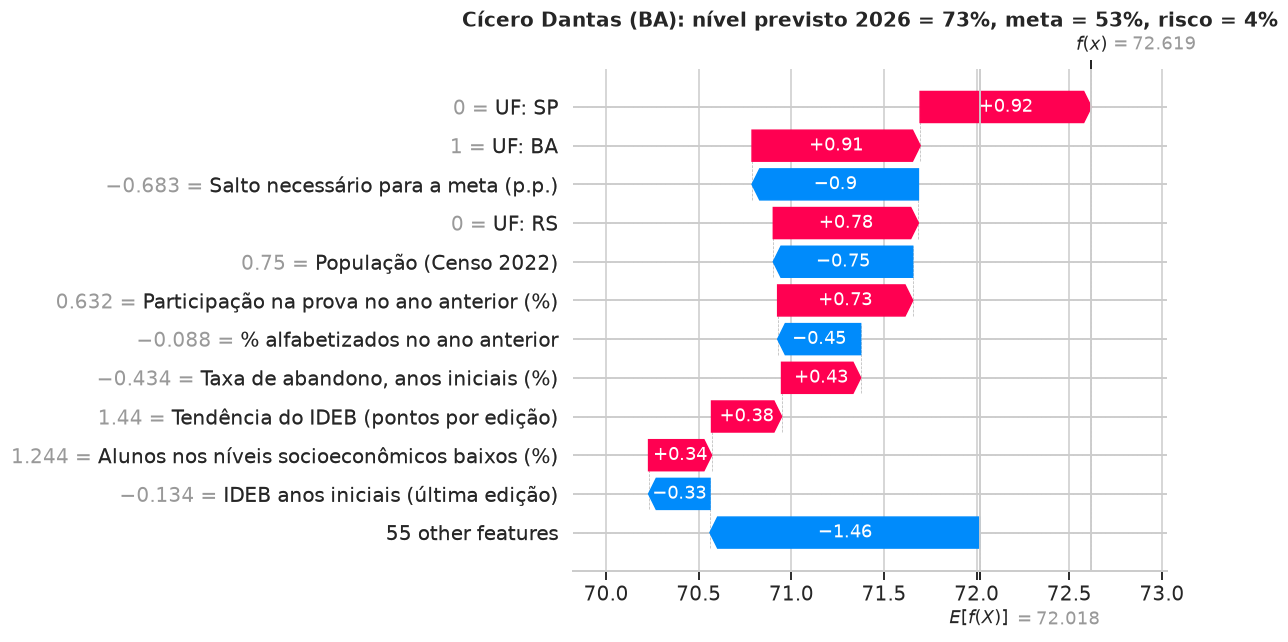

In [11]:
ranking = pd.read_csv("reports/municipios_risco_2026.csv")
alvo_risco = ranking.iloc[0]
alvo_ok = ranking[ranking["risco_2026"] < 0.05].iloc[0]
pos_risco = np.where(proj["id_municipio"].values == alvo_risco["id_municipio"])[0][0]
pos_ok = np.where(proj["id_municipio"].values == alvo_ok["id_municipio"])[0][0]

for pos, m, nome_fig in [(pos_risco, alvo_risco, "06_shap_local_risco"), (pos_ok, alvo_ok, "06_shap_local_consolidado")]:
    fig = plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_mun[pos], max_display=12, show=False)
    plt.title(f"{m['nome_municipio']} ({m['sigla_uf']}): nível previsto 2026 = {m['nivel_previsto_2026']:.0f}%, meta = {m['meta_2026']:.0f}%, risco = {100 * m['risco_2026']:.0f}%")
    plt.gcf().set_size_inches(11, 6)
    salvar(plt.gcf(), nome_fig)
    plt.show()

## 4. Respostas às perguntas estratégicas

### 4.1 Quais fatores mais impactam a alfabetização?

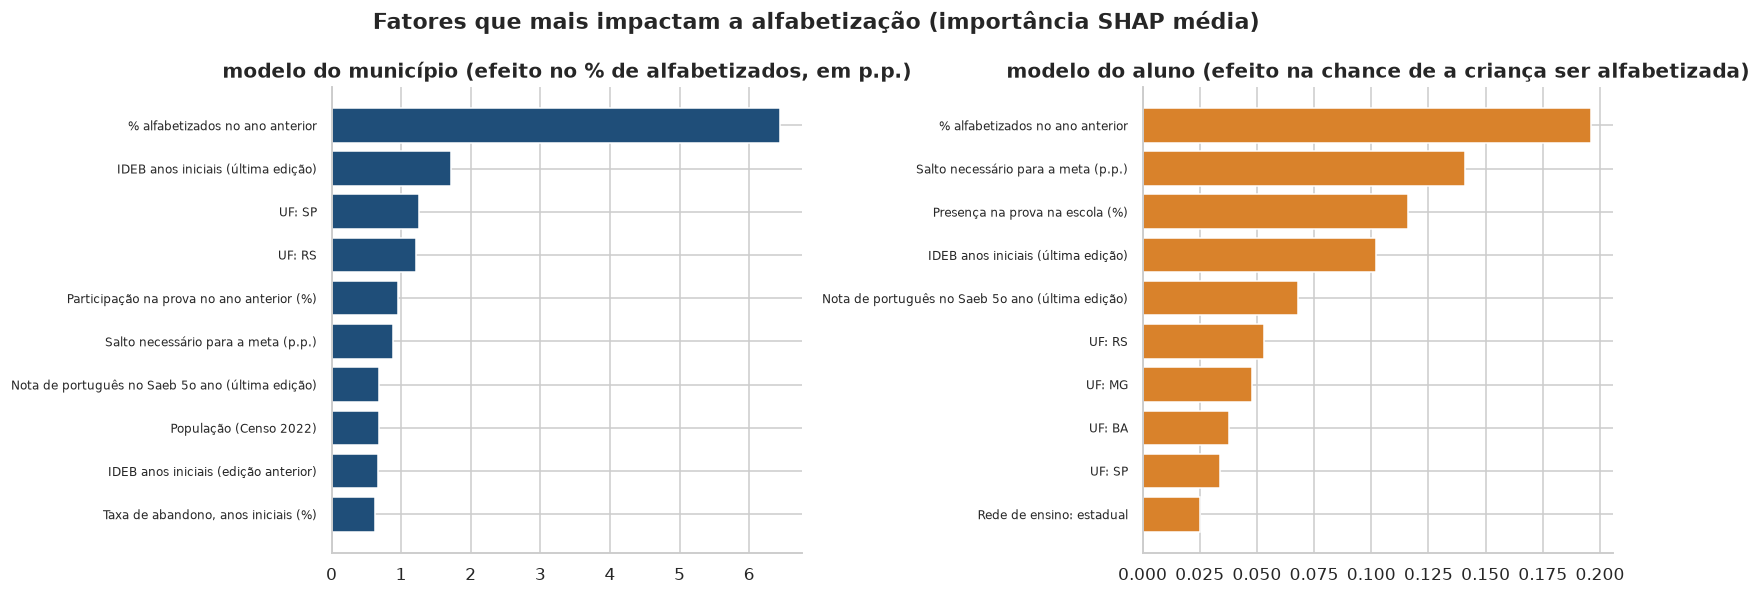

In [12]:
top_mun = imp_mun.head(10).copy()
top_mun["importancia_shap"] = top_mun["importancia_shap"].round(2)
top_alu = imp_aluno.head(10).copy()
top_alu["importancia_shap"] = top_alu["importancia_shap"].round(3)
fatores = pd.concat({"modelo do município (efeito no % de alfabetizados, em p.p.)": top_mun.set_index("variavel")["importancia_shap"], "modelo do aluno (efeito na chance de a criança ser alfabetizada)": top_alu.set_index("variavel")["importancia_shap"]}, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, (titulo, serie), cor in zip(axes, fatores.items(), [AZUL, LARANJA]):
    s = serie.dropna().sort_values()
    ax.barh(s.index, s.values, color=cor)
    ax.set_title(titulo)
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Fatores que mais impactam a alfabetização (importância SHAP média)", fontweight="bold")
salvar(fig, "06_fatores")
plt.show()

Resposta: nos dois grãos, o **histórico da rede** vem primeiro (o percentual do ano anterior e, no aluno, o salto necessário para a meta); depois o **IDEB dos anos iniciais** com a nota de português do 5º ano, a **UF** e a **participação na prova**. O fluxo escolar entra pelo abandono, com efeito de degrau, e pela distorção, com efeito pequeno; o porte do município aparece com sinal negativo (municípios menores alfabetizam mais). O contexto socioeconômico (INSE, PIB per capita) pesa menos do que se costuma supor, porque redes bem geridas alfabetizam mesmo em contextos pobres. E a UF continua sendo um fator em si, o que aponta para o papel do regime de colaboração estadual e para a diferença entre os instrumentos de avaliação.

### 4.2 Quais municípios apresentam maior risco educacional?

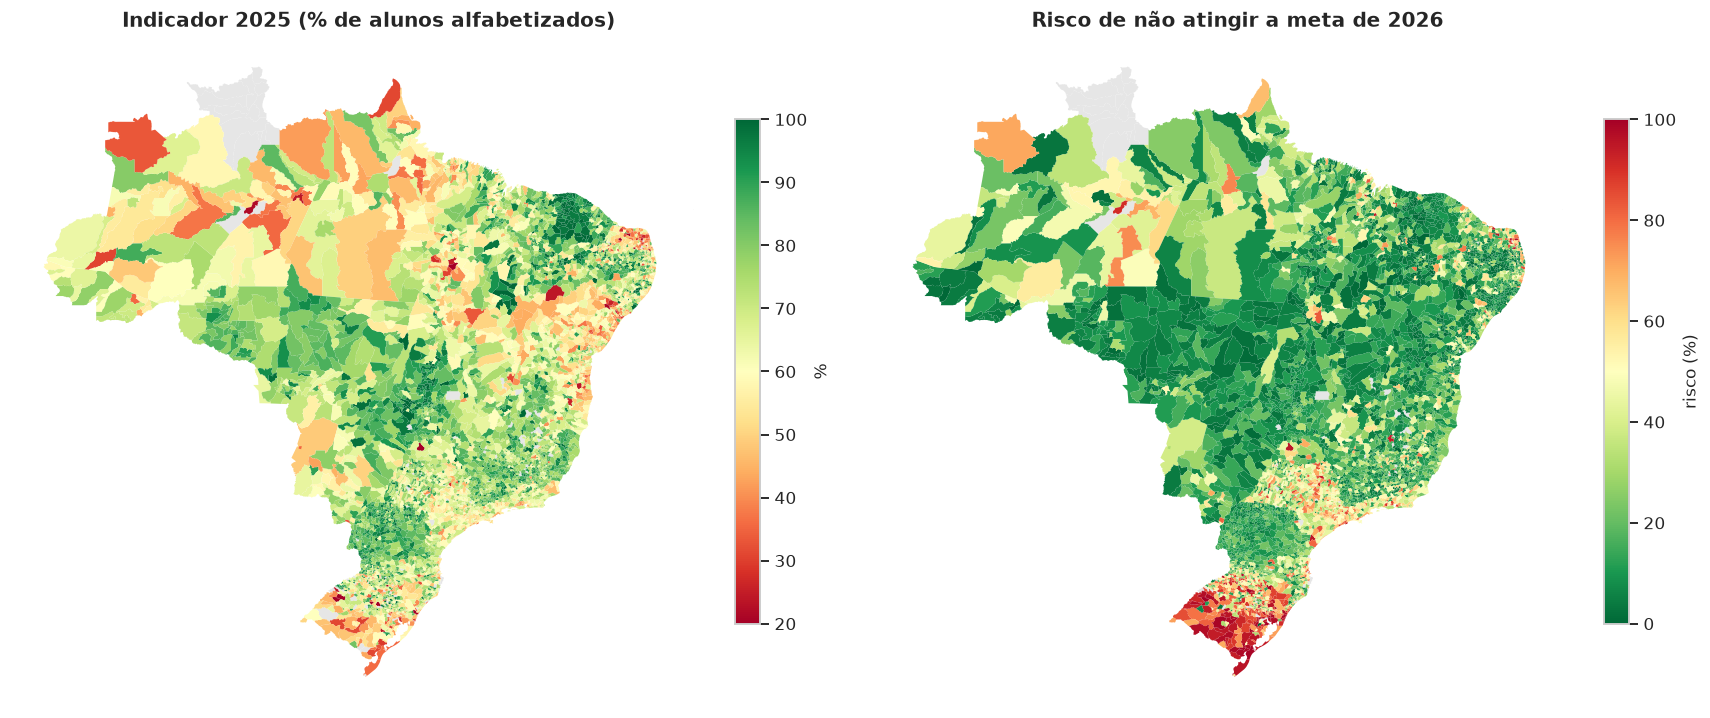

In [13]:
malha = carregar_malha()
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
mapa_municipios(ranking.set_index("id_municipio")["indicador_2025"].to_dict(), malha, ax=axes[0], cmap="RdYlGn", vmin=20, vmax=100, titulo="Indicador 2025 (% de alunos alfabetizados)", rotulo_barra="%")
mapa_municipios(ranking.set_index("id_municipio")["risco_2026"].mul(100).to_dict(), malha, ax=axes[1], cmap="RdYlGn_r", vmin=0, vmax=100, titulo="Risco de não atingir a meta de 2026", rotulo_barra="risco (%)")
salvar(fig, "06_mapa_risco")
plt.show()

In [14]:
colunas_lista = ["posicao", "nome_municipio", "sigla_uf", "indicador_2025", "meta_2026", "nivel_previsto_2026", "risco_2026", "distorcao_ai_pct", "ideb_ultimo"]
lista = ranking[colunas_lista].head(25).copy()
lista.columns = ["posição", "município", "UF", "indicador 2025 (%)", "meta 2026 (%)", "previsto 2026 (%)", "risco", rotulo("distorcao_ai_pct"), rotulo("ideb_ultimo")]
lista.round(2)

,posição,município,UF,indicador 2025 (%),meta 2026 (%),previsto 2026 (%),risco,"Distorção idade-série, anos iniciais (%)",IDEB anos iniciais (última edição)
0,1,Itacurubi,RS,20.59,80.00,44.38,1.00,6.1,6.1
1,2,Barra do Ribeiro,RS,37.81,73.90,45.78,0.99,9.5,5.4
2,3,São Pedro das Missões,RS,NaN,80.00,52.34,0.99,4.5,NaN
3,4,Amaral Ferrador,RS,24.62,74.91,48.18,0.99,7.4,5.3
4,5,Esmeralda,RS,35.56,80.00,53.91,0.99,5.2,5.9
5,6,Pedro Osório,RS,36.84,73.44,47.52,0.99,14.2,5.6
6,7,Cerrito,RS,53.70,77.28,51.69,0.99,8.5,5.4
7,8,Rio Grande,RS,35.73,66.59,41.18,0.99,15.7,5.5
8,9,Passo Fundo,RS,39.33,68.81,45.44,0.99,11.8,5.7
9,10,São Gabriel,RS,44.20,70.12,46.81,0.99,14.8,5.6


Resposta: a lista completa está em `reports/municipios_risco_2026.csv`, ordenada pelo risco. O mapa da esquerda mostra onde a alfabetização está baixa hoje; o da direita mostra onde a meta de 2026 tende a não ser atingida. Os dois não coincidem totalmente: municípios com nível baixo mas meta modesta ficam fora da lista de risco, e municípios com nível médio e meta ambiciosa entram. É a diferença entre "quem está mal" e "quem vai ficar aquém do combinado", e a política pública precisa das duas leituras.

### 4.3 Quais regiões possuem padrões semelhantes?

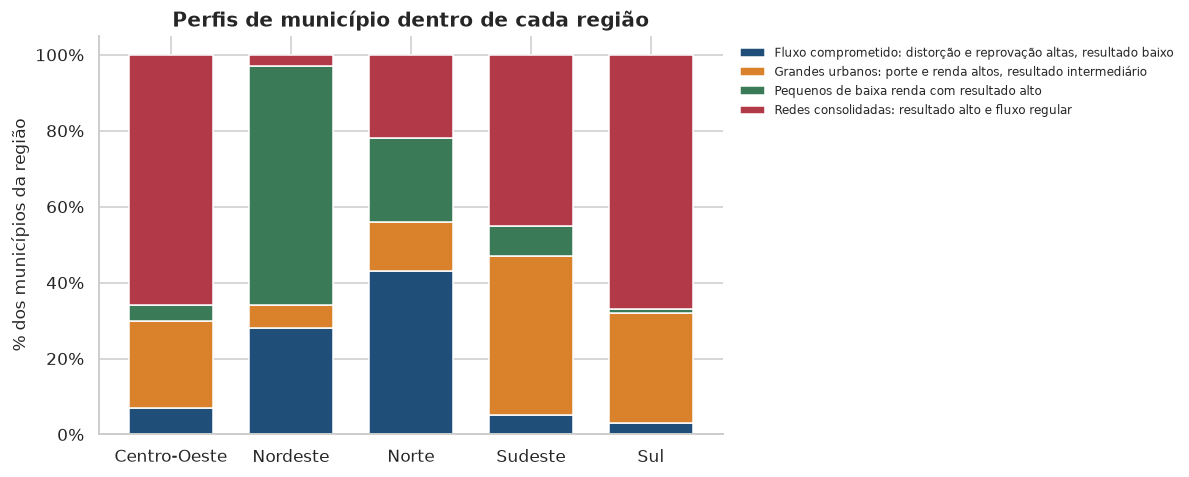

nome_regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul,total
perfil,,,,,,
"Fluxo comprometido: distorção e reprovação altas, resultado baixo",32,501,193,75,37,838
"Grandes urbanos: porte e renda altos, resultado intermediário",109,101,58,693,337,1298
Pequenos de baixa renda com resultado alto,17,1134,99,126,10,1386
Redes consolidadas: resultado alto e fluxo regular,309,57,99,743,793,2001


In [15]:
perfis = pd.read_csv("reports/perfis_municipios.csv")
comp = pd.crosstab(perfis["perfil"], perfis["nome_regiao"])
comp["total"] = comp.sum(axis=1)
comp_pct = pd.crosstab(perfis["perfil"], perfis["nome_regiao"], normalize="columns").mul(100).round(0)
fig, ax = plt.subplots(figsize=(11, 4.5))
comp_pct.T.plot.bar(stacked=True, ax=ax, color=PALETA[: len(comp_pct)], width=0.7)
ax.set_ylabel("% dos municípios da região")
ax.set_xlabel("")
ax.set_title("Perfis de município dentro de cada região")
ax.legend(title="", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.tick_params(axis="x", rotation=0)
fmt_pct(ax, "y")
salvar(fig, "06_perfis_por_regiao")
plt.show()
comp

Resposta: os perfis (notebook 05) cortam as regiões. O perfil de fluxo comprometido concentra-se no Norte e no Nordeste, mas todo o país tem municípios nele; o perfil consolidado inclui boa parte do Nordeste (Ceará, Piauí, Paraíba). "Padrões semelhantes" são grupos de condições, não macrorregiões, e a matriz perfil x risco em `reports/perfis_municipios.csv` é o instrumento para tratar municípios parecidos com a mesma estratégia.

### 4.4 Como prever municípios que podem não atingir metas futuras?

In [16]:
uf_risco = ranking.groupby("sigla_uf").agg(municipios=("id_municipio", "size"), em_risco=("risco_2026", lambda s: int((s >= 0.5).sum())), risco_medio=("risco_2026", "mean"), salto_mediano=("salto_necessario_pp", "median")).sort_values("risco_medio", ascending=False)
uf_risco["% em risco"] = (100 * uf_risco["em_risco"] / uf_risco["municipios"]).round(0)
backtest = meta_municipio["backtest_2024_para_2025"]
print(f"backtest 2024 -> 2025: AUC do risco = {backtest['auc_risco_teste_2025']:.3f}, Spearman do nível = {backtest['spearman_teste_2025']:.2f}, viés do nível = {backtest['vies_teste_2025']:.1f} p.p.")
uf_risco.round(2)

backtest 2024 -> 2025: AUC do risco = 0.772, Spearman do nível = 0.69, viés do nível = -7.3 p.p.


,municipios,em_risco,risco_medio,salto_mediano,% em risco
sigla_uf,,,,,
RS,476,331,0.63,10.09,70.0
SP,629,262,0.46,2.12,42.0
RJ,92,33,0.42,2.95,36.0
AM,60,15,0.35,6.79,25.0
SC,284,70,0.35,0.96,25.0
RN,163,46,0.33,3.32,28.0
SE,75,17,0.29,2.81,23.0
MA,217,32,0.26,-4.46,15.0
PE,184,24,0.25,-2.92,13.0


Resposta: com o modelo de nível reajustado a cada ano e comparado com a meta do ano seguinte. O backtest de 2024 para 2025 mostra que o ranking se sustenta fora do tempo (AUC do risco próximo de 0,77), e que o erro típico é de nível, não de ordem, quando há um choque nacional como o de 2025. Para 2026, a tabela por UF mostra onde o número de municípios em risco é maior e qual o salto mediano exigido pela meta; para 2027 em diante, o mesmo fluxo roda com o dado novo (`make abt` e `make train`).

### 4.5 Quais variáveis possuem maior influência nos modelos?

In [17]:
influencia = pd.concat({
    "município (SHAP, p.p.)": imp_mun.set_index("variavel")["importancia_shap"].head(12),
    "município (permutação, +erro p.p.)": perm.set_index("variavel")["aumento_do_erro_pp"].head(12),
    "aluno (SHAP, log-odds)": imp_aluno.set_index("variavel")["importancia_shap"].head(12),
}, axis=1)
influencia.round(3)

,"município (SHAP, p.p.)","município (permutação, +erro p.p.)","aluno (SHAP, log-odds)"
variavel,,,
% alfabetizados no ano anterior,6.441,4.715,0.196
IDEB anos iniciais (última edição),1.721,0.615,0.102
UF: SP,1.249,NaN,0.034
UF: RS,1.215,NaN,0.053
Participação na prova no ano anterior (%),0.951,0.398,0.024
Salto necessário para a meta (p.p.),0.882,0.207,0.141
População (Censo 2022),0.681,0.187,NaN
Nota de português no Saeb 5o ano (última edição),0.676,0.220,0.068
IDEB anos iniciais (edição anterior),0.667,0.096,NaN


Resposta: as duas medidas (SHAP e permutação) concordam no topo: percentual do ano anterior, UF, IDEB, participação na prova, nota de português e salto necessário. A permutação, que mede o quanto o erro sobe quando a variável é embaralhada, confirma que o histórico é a variável da qual o modelo mais depende (o erro sobe quase 5 pontos sem ela), seguido da UF. A tabela completa fica em `reports/`.

In [18]:
Path("reports").mkdir(exist_ok=True)
imp_mun.round(4).to_csv("reports/importancia_shap_municipio.csv", index=False)
imp_aluno.round(4).to_csv("reports/importancia_shap_aluno.csv", index=False)
comparacao_variantes.round(4).to_csv("reports/modelo_aluno_variantes.csv")
perm.round(4).to_csv("reports/importancia_permutacao_municipio.csv", index=False)
uf_risco.round(3).to_csv("reports/risco_2026_por_uf.csv")
print("tabelas salvas em reports/")

tabelas salvas em reports/


## 5. Calibração e incerteza das métricas

Um AUC isolado diz quanto o modelo ordena, não quanto se pode confiar no número que ele produz nem se a diferença para outro modelo é maior do que o acaso. Esta seção responde às duas perguntas com as predições já salvas em `models/` (nada é retreinado):

- **calibração**: quando o modelo diz 70%, acontece em 70% dos casos? Medida pelo escore de Brier (erro quadrático da probabilidade; a referência é o Brier de um modelo que responde sempre a taxa base) e pela curva de calibração por faixa;
- **incerteza**: intervalo de confiança de 95% do AUC por bootstrap de municípios inteiros (reamostrar municípios, e não linhas, respeita a dependência entre alunos da mesma rede); e a estatística KS, distância máxima entre as distribuições acumuladas das duas classes.

In [19]:
from sklearn.metrics import roc_auc_score
from src.evaluation.metricas import brier, curva_calibracao, ic_bootstrap, ks, risco_de_nao_atingir

pred_aluno = pd.read_parquet("models/modelo_aluno_pred_2025.parquet")
bt = pd.read_parquet("models/modelo_municipio_backtest_2025.parquet")
oof_mun = pd.read_parquet("models/modelo_municipio_oof.parquet")
y_a, p_a, w_a = pred_aluno["alfabetizado"].values, pred_aluno["proba"].values, pred_aluno["peso"].values
y_m = (1 - bt["atingiu_meta_t"]).values  # classe de interesse: não atingiu a meta
p_m = bt["risco"].values

ic_aluno = ic_bootstrap(y_a, p_a, pred_aluno["id_municipio"].values, roc_auc_score, n_reamostras=100, sample_weight=w_a, seed=SEED)
ic_mun = ic_bootstrap(y_m, p_m, bt["id_municipio"].values, roc_auc_score, n_reamostras=500, seed=SEED)
taxa_a, taxa_m = np.average(y_a, weights=w_a), y_m.mean()
incerteza = pd.DataFrame({
    "aluno, teste 2025": {"AUC": ic_aluno["estimativa"], "IC 95% inferior": ic_aluno["ic_inferior"], "IC 95% superior": ic_aluno["ic_superior"], "KS": ks(y_a, p_a, w_a), "Brier": brier(y_a, p_a, w_a), "Brier da taxa base": taxa_a * (1 - taxa_a)},
    "município, risco no backtest 2025": {"AUC": ic_mun["estimativa"], "IC 95% inferior": ic_mun["ic_inferior"], "IC 95% superior": ic_mun["ic_superior"], "KS": ks(y_m, p_m), "Brier": brier(y_m, p_m), "Brier da taxa base": taxa_m * (1 - taxa_m)},
}).T
incerteza.round(4).to_csv("reports/intervalos_confianca.csv")
incerteza.round(3)

,AUC,IC 95% inferior,IC 95% superior,KS,Brier,Brier da taxa base
"aluno, teste 2025",0.646,0.638,0.656,0.210,0.216,0.226
"município, risco no backtest 2025",0.772,0.758,0.785,0.408,0.243,0.203


O intervalo do AUC do aluno tem menos de 0,02 de largura: com dois milhões de alunos em 5,4 mil municípios, a diferença entre as famílias de modelo na busca (0,66 a 0,67) e entre as duas variantes (0,641 e 0,646) é da ordem do ruído amostral. A escolha entre elas é de custo e de disponibilidade das variáveis, não de desempenho. No município a largura é maior (poucos casos por UF), e é ela que deve ser lida antes de comparar formulações.

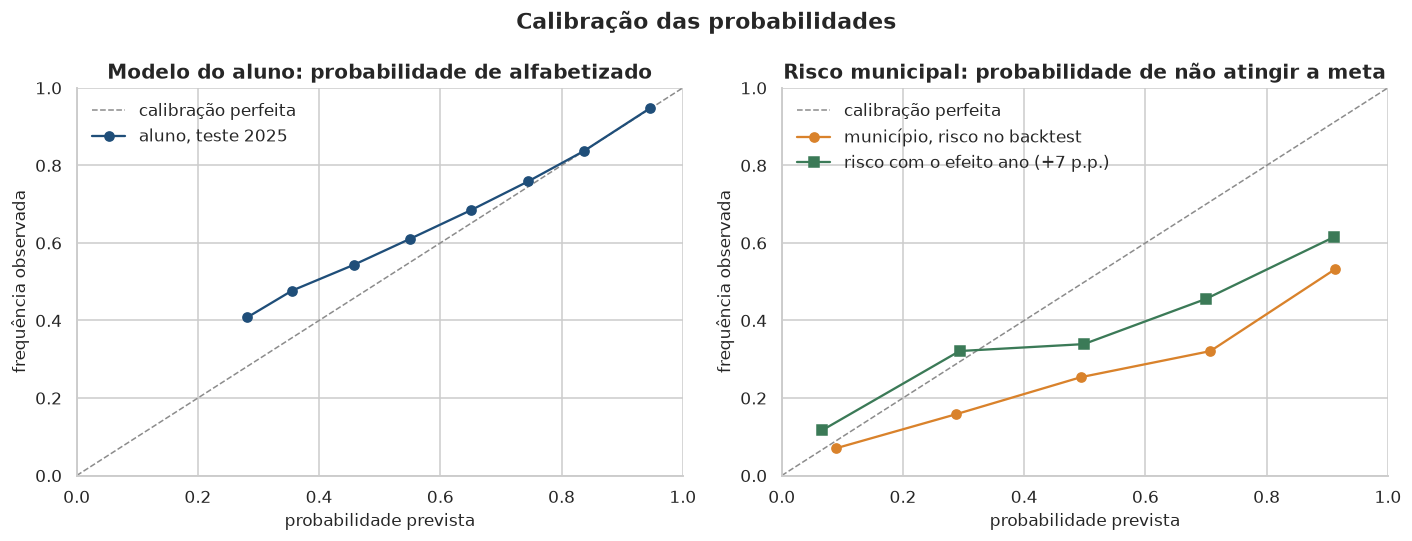

Brier do risco: sem correção 0.243 | com o efeito ano 0.189 | taxa base 0.203


In [20]:
# calibracao: o risco municipal no backtest e o mesmo risco com o efeito ano conhecido a posteriori
vies = meta_municipio["backtest_2024_para_2025"]["vies_teste_2025"]
p_m_corrigido = risco_de_nao_atingir(bt["nivel_previsto"].values - vies, bt["meta_t"].values, oof_mun["residuo"].values)
cal = {
    "aluno, teste 2025": curva_calibracao(y_a, p_a, 10, w_a),
    "município, risco no backtest": curva_calibracao(y_m, p_m, 5),
    "município, risco com o efeito ano": curva_calibracao(y_m, p_m_corrigido, 5),
}
incerteza.loc["município, risco com o efeito ano", ["AUC", "Brier"]] = [roc_auc_score(y_m, p_m_corrigido), brier(y_m, p_m_corrigido)]
incerteza.round(4).to_csv("reports/intervalos_confianca.csv")
pd.concat(cal, names=["modelo"]).round(3).to_csv("reports/calibracao.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (nome, cor) in zip(axes, [("aluno, teste 2025", AZUL), ("município, risco no backtest", LARANJA)]):
    c = cal[nome][cal[nome]["n"] >= 100]  # faixas com menos de 100 casos não são mostradas
    ax.plot([0, 1], [0, 1], "--", color=CINZA, lw=1, label="calibração perfeita")
    ax.plot(c["prevista"], c["observada"], "o-", color=cor, label=nome)
    if nome.startswith("município"):
        c2 = cal["município, risco com o efeito ano"]
        ax.plot(c2["prevista"], c2["observada"], "s-", color=VERDE, label="risco com o efeito ano (+7 p.p.)")
    ax.set_xlabel("probabilidade prevista")
    ax.set_ylabel("frequência observada")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="upper left")
axes[0].set_title("Modelo do aluno: probabilidade de alfabetizado")
axes[1].set_title("Risco municipal: probabilidade de não atingir a meta")
fig.suptitle("Calibração das probabilidades", fontweight="bold")
salvar(fig, "06_calibracao")
plt.show()
print("Brier do risco: sem correção", round(brier(y_m, p_m), 3), "| com o efeito ano", round(brier(y_m, p_m_corrigido), 3), "| taxa base", round(taxa_m * (1 - taxa_m), 3))

Os dois painéis contam a mesma história de ângulos diferentes.

- **Aluno.** O Brier (0,216) fica abaixo do da taxa base (0,226) e as faixas altas estão na diagonal. Nas faixas baixas a frequência observada supera a prevista em 5 a 12 pontos: o modelo treinado em 2024 subestima a alfabetização de 2025, o mesmo salto nacional que aparece no viés do modelo municipal. A ordenação se mantém; o valor absoluto da probabilidade carrega o deslocamento do ano.
- **Município.** O risco do backtest ordena bem (AUC 0,77) mas está inflado: na faixa de 80% a 100% de risco, 52% dos municípios de fato não atingiram a meta. O Brier (0,243) fica acima do da taxa base (0,203), o que quer dizer que, como probabilidade calibrada, o risco de 2024 aplicado a 2025 é pior do que responder a taxa média. Com o efeito ano conhecido a posteriori (+7,3 p.p. no nível previsto), o mesmo risco passa a Brier 0,189, abaixo da taxa base, e a curva se aproxima da diagonal. É a evidência direta de que o efeito ano é a maior fonte de erro da projeção e a razão de ele entrar na incerteza de 2026 (decisão D29).

A leitura para o gestor: o risco de 2026 é um instrumento de ordenação e de corte (acima de 50% entra na lista de atenção), não uma probabilidade a ser lida ao pé da letra. O intervalo do efeito ano é o que separa uma lista de 914 de uma de 936 municípios.

In [21]:
extras_path = Path("models/extras.json")
extras = json.loads(extras_path.read_text(encoding="utf-8")) if extras_path.exists() else {}
extras.update({
    "auc_aluno_ic95": f"{ic_aluno['ic_inferior']:.3f} a {ic_aluno['ic_superior']:.3f}".replace(".", ","),
    "auc_risco_ic95": f"{ic_mun['ic_inferior']:.3f} a {ic_mun['ic_superior']:.3f}".replace(".", ","),
    "brier_aluno": f"{brier(y_a, p_a, w_a):.3f}".replace(".", ","),
    "brier_risco": f"{brier(y_m, p_m):.3f}".replace(".", ","),
    "brier_risco_com_efeito_ano": f"{brier(y_m, p_m_corrigido):.3f}".replace(".", ","),
    "ks_aluno": f"{ks(y_a, p_a, w_a):.3f}".replace(".", ","),
    "ks_risco": f"{ks(y_m, p_m):.3f}".replace(".", ","),
})
extras_path.write_text(json.dumps(extras, ensure_ascii=False, indent=2), encoding="utf-8")
print(extras)

{'silhueta': '0,136', 'davies_bouldin': '1,937', 'ari': '0,50', 'auc_salto_2025': '0,74', 'auc_aluno_ic95': '0,638 a 0,656', 'auc_risco_ic95': '0,758 a 0,785', 'brier_aluno': '0,216', 'brier_risco': '0,243', 'brier_risco_com_efeito_ano': '0,189', 'ks_aluno': '0,210', 'ks_risco': '0,408'}


## 6. Falsificação e extrapolação do modelo do aluno

Os mesmos testes do notebook 04, adaptados ao grão do aluno. Como reajustar o modelo em 1,85 milhão de linhas leva perto de uma hora, os testes que exigem reajuste rodam em uma amostra estratificada de 300 mil alunos de 2024 com os hiperparâmetros já escolhidos, e comparam sempre com a mesma amostra e o mesmo protocolo; os testes sobre predições usam o teste de 2025 (amostra de 300 mil para o bootstrap pareado, que recalcula o AUC centenas de vezes).

1. **Alvo embaralhado dentro do município**: a taxa de cada município é preservada, a relação entre aluno e variáveis é destruída; o AUC fora da amostra deve ir para 0,5.
2. **Modelo contra a regra simples**: o score "% alfabetizados do município no ano anterior" contra o modelo, com IC pareado.
3. **Variante completa contra variante antes da prova**: a diferença de 0,005 de AUC é maior que o ruído?
4. **UF nunca vista**: cinco folds que separam estados inteiros, contra cinco folds que separam municípios, na mesma amostra.

In [22]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold
from src.preprocessing.splits import amostra_estratificada
from src.evaluation.validacao import diferenca_bootstrap_pareada, embaralhar_dentro_de_grupos, validar_por_grupos

amostra = amostra_estratificada(treino, 300_000, "alfabetizado", seed=SEED)
x_am, y_am = preparar_xy(amostra, ga, "alfabetizado")
w_am, g_am, uf_am = amostra["peso"].values, amostra["id_municipio"].values, amostra["sigla_uf"].values
def novo_modelo():
    return build_pipeline(ga, LGBMClassifier(n_estimators=600, learning_rate=0.03, random_state=SEED, n_jobs=-1, verbose=-1, **hiper))

# 1. alvo verdadeiro e alvo embaralhado dentro do municipio, mesma validacao por municipio (3 folds)
_, oof_real = validar_por_grupos(novo_modelo(), x_am, y_am, pd.Series(g_am), n_splits=3, sample_weight=w_am)
y_emb = embaralhar_dentro_de_grupos(y_am.values, g_am, seed=SEED)
_, oof_emb = validar_por_grupos(novo_modelo(), x_am, pd.Series(y_emb), pd.Series(g_am), n_splits=3, sample_weight=w_am)

# 4. cinco folds por UF na mesma amostra
oof_uf = np.full(len(y_am), np.nan)
for tr_i, va_i in GroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(x_am, y_am, uf_am):
    m = novo_modelo().fit(x_am.iloc[tr_i], y_am.iloc[tr_i], modelo__sample_weight=w_am[tr_i])
    oof_uf[va_i] = m.predict_proba(x_am.iloc[va_i])[:, 1]

falsificacao_aluno = pd.DataFrame({
    "AUC fora da amostra": {
        "alvo verdadeiro, folds por município": roc_auc_score(y_am, oof_real, sample_weight=w_am),
        "alvo embaralhado dentro do município, folds por município": roc_auc_score(y_emb, oof_emb, sample_weight=w_am),
        "alvo verdadeiro, folds por UF (estado nunca visto)": roc_auc_score(y_am, oof_uf, sample_weight=w_am),
    }
})
falsificacao_aluno.round(3)

,AUC fora da amostra
"alvo verdadeiro, folds por município",0.665
"alvo embaralhado dentro do município, folds por município",0.655
"alvo verdadeiro, folds por UF (estado nunca visto)",0.641


In [23]:
# AUC por UF nos dois protocolos: quanto do sinal e "conhecer o estado"?
por_uf_aluno = pd.DataFrame({"uf": uf_am, "y": y_am.values, "w": w_am, "municipio": oof_real, "uf_excluida": oof_uf})
auc_uf_aluno = por_uf_aluno.groupby("uf").apply(lambda g: pd.Series({
    "alunos": len(g),
    "AUC folds por município": roc_auc_score(g["y"], g["municipio"], sample_weight=g["w"]),
    "AUC estado nunca visto": roc_auc_score(g["y"], g["uf_excluida"], sample_weight=g["w"]),
}), include_groups=False)
auc_uf_aluno["diferença"] = auc_uf_aluno["AUC estado nunca visto"] - auc_uf_aluno["AUC folds por município"]
auc_uf_aluno.round(3).to_csv("reports/extrapolacao_uf_aluno.csv")
print("mediana da diferença dentro da UF:", round(auc_uf_aluno["diferença"].median(), 3))
auc_uf_aluno.sort_values("diferença").round(3)

mediana da diferença dentro da UF: -0.002


,alunos,AUC folds por município,AUC estado nunca visto,diferença
uf,,,,
CE,14289.0,0.732,0.720,-0.012
TO,2778.0,0.576,0.568,-0.008
AP,1866.0,0.552,0.544,-0.008
PB,5076.0,0.612,0.604,-0.007
MG,29264.0,0.594,0.588,-0.006
PA,13326.0,0.593,0.588,-0.006
SP,64180.0,0.605,0.600,-0.005
MA,10259.0,0.607,0.602,-0.005
RJ,20349.0,0.630,0.626,-0.004


In [24]:
# 2 e 3. bootstrap pareado no teste de 2025 (amostra estratificada de 300 mil)
teste_am = amostra_estratificada(teste.assign(proba_completo=proba_completo, proba_antes=proba_antes), 300_000, "alfabetizado", seed=SEED)
col_hist = [c for c in ga["historico"] if c.startswith("indicador_t1")][0]
regra = teste_am[col_hist].fillna(teste_am[col_hist].median()).values
comparacoes_aluno = pd.DataFrame({
    "modelo completo contra regra (% alfabetizados no ano anterior)": diferenca_bootstrap_pareada(teste_am["alfabetizado"].values, teste_am["proba_completo"].values, regra, teste_am["id_municipio"].values, roc_auc_score, n_reamostras=200, sample_weight=teste_am["peso"].values, seed=SEED),
    "modelo completo contra variante antes da prova": diferenca_bootstrap_pareada(teste_am["alfabetizado"].values, teste_am["proba_completo"].values, teste_am["proba_antes"].values, teste_am["id_municipio"].values, roc_auc_score, n_reamostras=200, sample_weight=teste_am["peso"].values, seed=SEED),
}).T.rename(columns={"metrica_a": "AUC do modelo completo", "metrica_b": "AUC do comparado", "diferenca": "diferença", "ic_inferior": "IC 95% inferior", "ic_superior": "IC 95% superior"})
pd.concat([falsificacao_aluno.assign(bloco="falsificação"), comparacoes_aluno.assign(bloco="bootstrap pareado")]).round(4).to_csv("reports/falsificacao_aluno.csv")
pd.DataFrame({"id_municipio": teste["id_municipio"].values, "proba_antes_da_prova": proba_antes}).to_parquet("models/modelo_aluno_pred_2025_antes.parquet", index=False)
comparacoes_aluno.round(4)

,AUC do modelo completo,AUC do comparado,diferença,IC 95% inferior,IC 95% superior,n_reamostras
modelo completo contra regra (% alfabetizados no ano anterior),0.646,0.6401,0.0058,0.0038,0.0086,200.0
modelo completo contra variante antes da prova,0.646,0.6411,0.0049,0.0030,0.0071,200.0


Os resultados, em ordem, e o que eles dizem sobre o modelo.

1. **Alvo embaralhado dentro do município: AUC 0,655, contra 0,665 com o alvo verdadeiro.** O embaralhamento preserva a taxa de cada município e destrói qualquer relação entre a criança e as suas variáveis; um modelo que ainda ordena está lendo o município, não o aluno. E é o que acontece: quase toda a capacidade de ordenação (0,655 de 0,665) vem de saber em que município a criança está. O que as variáveis de escola (presença e tamanho) acrescentam dentro do município vale 0,01 de AUC. A permutação total, que leva o modelo ao acaso, foi feita no notebook 04 para o município. Este teste quantifica o que a decomposição de variância já sugeria: o modelo do aluno é, na prática, um modelo do contexto municipal com um ganho marginal da escola, e serve para ordenar redes e escolas, não crianças.
2. **Modelo contra a regra simples: 0,646 contra 0,640, diferença de +0,006 com IC 95% de 0,004 a 0,009.** Estatisticamente diferente de zero e praticamente irrelevante: uma regra de uma variável ("% alfabetizados do município no ano anterior") chega a 0,64. O algoritmo não é o gargalo; o dado é.
3. **Variante completa contra antes da prova: +0,005 (0,003 a 0,007).** A diferença é real, mas pequena; a escolha entre as variantes continua sendo por disponibilidade das variáveis, não por desempenho.
4. **Estado nunca visto: 0,641 contra 0,665 na mesma amostra**, e dentro de cada UF a mediana da diferença é de -0,002 (Ceará -0,012, o maior). Mesmo padrão do modelo municipal: o que se perde é o patamar do estado, não a ordenação dentro dele.

O conjunto é coerente com tudo o que veio antes (85% da variância dentro da escola, SHAP dominado pelo histórico da rede, UF explicando um terço da variação entre municípios) e fixa a leitura para o gestor: o valor do modelo do aluno está em apontar onde o risco se concentra, e quase todo esse valor já está no histórico do município. As tabelas ficam em `reports/falsificacao_aluno.csv` e `reports/extrapolacao_uf_aluno.csv`; as predições da variante antes da prova, em `models/modelo_aluno_pred_2025_antes.parquet`.

In [25]:
extras = json.loads(extras_path.read_text(encoding="utf-8"))
extras.update({
    "auc_aluno_alvo_embaralhado": f"{falsificacao_aluno.iloc[1, 0]:.3f}".replace(".", ","),
    "auc_aluno_uf_nunca_vista": f"{falsificacao_aluno.iloc[2, 0]:.3f}".replace(".", ","),
    "auc_aluno_amostra_municipio": f"{falsificacao_aluno.iloc[0, 0]:.3f}".replace(".", ","),
    "dif_aluno_vs_regra": f"{comparacoes_aluno.iloc[0]['diferença']:.3f} (IC {comparacoes_aluno.iloc[0]['IC 95% inferior']:.3f} a {comparacoes_aluno.iloc[0]['IC 95% superior']:.3f})".replace(".", ","),
    "dif_completo_vs_antes": f"{comparacoes_aluno.iloc[1]['diferença']:.3f} (IC {comparacoes_aluno.iloc[1]['IC 95% inferior']:.3f} a {comparacoes_aluno.iloc[1]['IC 95% superior']:.3f})".replace(".", ","),
})
extras_path.write_text(json.dumps(extras, ensure_ascii=False, indent=2), encoding="utf-8")
print({k: v for k, v in extras.items() if "aluno" in k or "dif_" in k})

{'auc_aluno_ic95': '0,638 a 0,656', 'brier_aluno': '0,216', 'ks_aluno': '0,210', 'auc_aluno_alvo_embaralhado': '0,655', 'auc_aluno_uf_nunca_vista': '0,641', 'auc_aluno_amostra_municipio': '0,665', 'dif_aluno_vs_regra': '0,006 (IC 0,004 a 0,009)', 'dif_completo_vs_antes': '0,005 (IC 0,003 a 0,007)'}


## 7. Uma nota sobre causalidade

Tudo o que o SHAP diz é sobre o modelo, não sobre o mundo: "distorção idade-série alta reduz o nível previsto" não significa que reduzir a distorção por decreto elevaria a alfabetização. As variáveis de fluxo são sintomas de uma rede que retém e reprova, e a intervenção certa pode ser anterior (alfabetização no 1º ano, busca ativa, formação). Para estimar o efeito de uma intervenção seria preciso um desenho causal (pareamento por escore de propensão, diferenças em diferenças entre redes que adotaram e não adotaram um programa), que fica como evolução futura. O que o modelo entrega hoje é triagem e priorização com base em evidência.